### Parallel Workflow

Here we are creating parallel workflow with langgraph

In [11]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

### Problem Statement

Build a **parallel workflow using LangGraph in Python** that processes a customer review through three independent tasks running in parallel:

1. Generate a **summary** of the review.
2. Analyze the **sentiment** of the review.
3. Extract the **key topics/keywords** from the review.

After all three tasks are completed, use a final node to **combine their results into a single structured response**.


Task1 - 
1) Summary -> str
2) Sentiment -> Literal['Positive', 'Negative'] and score
3) Keywords -> List[str]

In [3]:
load_dotenv()

True

In [5]:
model = ChatOpenAI(model='gpt-5.4-mini', max_completion_tokens=300)
model

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14', 'langchain-openai': '1.3.5'}}, output_version=None, profile={'name': 'GPT-5.4 mini', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001A8A0089E50>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001A8A008A350>, root_client=<openai.OpenAI objec

In [12]:
# sentiment pydantic class
class SemanticSchema(BaseModel):
    sentiment: Literal['Positive', 'Negative'] = Field(description="Defines the sentiment of the customer review.")
    score: int = Field(description="score represents the intensity of the sentiment", ge=0, le=10)

In [14]:
# Semantic Model
semantic_model = model.with_structured_output(schema=SemanticSchema)

In [15]:
# Keyword pydantic class
class KeywordSchema(BaseModel):
    keywords: list[str] = Field(description="This field represents the list of important keywords in the customer review.")

In [16]:
# Keyword model
keyword_model = model.with_structured_output(KeywordSchema) 

In [34]:
# Customer Review State
class ReviewState(TypedDict):
    product: str
    review: str
    summary: str
    sentiment: Literal['Positive', 'Negative']
    sentiment_score: int
    keywords: list[str]

In [57]:
def generate_review(state: ReviewState) -> ReviewState:
    product = state['product']
    review = model.invoke(f"Give me the customer review in 50 words about product: {product}. The review can be positive or negative").content
    return {"review": review}

In [58]:
def generate_summary(state: ReviewState) -> ReviewState:
    review = state['review']
    summary = model.invoke(f"Give me the summary of review: {review}").content

    return {"summary": summary}

In [59]:
def get_sentiment(state: ReviewState) -> ReviewState:
    review = state['review']
    sentiment_res = semantic_model.invoke(f"Give the sentiment along with the sentiment score 0 to 10 for review: {review}")

    return {"sentiment": sentiment_res.sentiment, "sentiment_score": sentiment_res.score}

In [60]:
def get_keywords(state: ReviewState) -> ReviewState:
    review = state['review']
    keywords = keyword_model.invoke(f"Give the important keywords in the review: {review}")

    return {"keywords": keywords}

In [61]:
def get_review_metrics(state: ReviewState) -> ReviewState:
    review = state['review']
    summary = state['summary']
    sentiment = state['sentiment']
    score = state['sentiment_score']
    keywords = state['keywords']

    print(f"Review: {review}\n")
    print(f"summary: {summary}\n")
    print(f"sentiment: {sentiment}\n")
    print(f"score: {score}\n")
    print(f"keywords: {keywords}\n")

    return state

In [62]:
# Graph object
graph = StateGraph(ReviewState)

In [63]:
# Graph nodes
graph.add_node('generate_review', generate_review)
graph.add_node('generate_summary', generate_summary)
graph.add_node('get_sentiment', get_sentiment)
graph.add_node('get_keywords', get_keywords)
graph.add_node('get_review_metrics', get_review_metrics)

# Graph edges
graph.add_edge(START, 'generate_review')
graph.add_edge('generate_review', 'generate_summary')
graph.add_edge('generate_review', 'get_sentiment')
graph.add_edge('generate_review', 'get_keywords')
graph.add_edge('generate_summary', 'get_review_metrics')
graph.add_edge('get_sentiment', 'get_review_metrics')
graph.add_edge('get_keywords', 'get_review_metrics')
graph.add_edge('get_review_metrics', END)

# Compile graph
workflow = graph.compile()

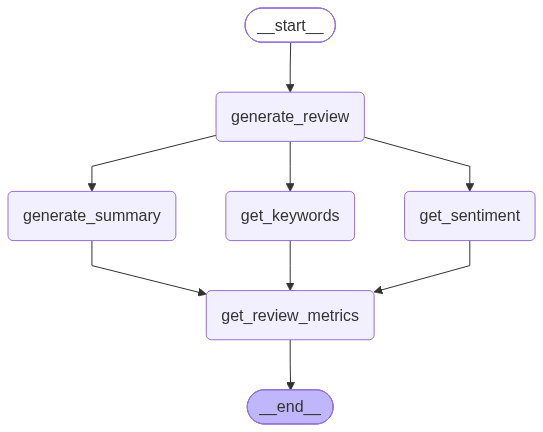

In [64]:
workflow

In [66]:
initial_state = {'product': 'iphone'}
res = workflow.invoke(initial_state)

Review: The iPhone delivers a smooth, premium experience with fast performance, a sharp display, and excellent camera quality. Its build feels solid and elegant, and iOS is easy to use. Battery life could be better, and the high price is a drawback, but overall it remains a reliable, impressive smartphone.

summary: The review says the iPhone offers a smooth, premium experience with strong performance, a sharp display, excellent cameras, and a solid, elegant build. iOS is praised for being easy to use. The main downsides are average battery life and a high price, but overall it’s seen as a reliable, impressive smartphone.

sentiment: Positive

score: 8

keywords: keywords=['iPhone', 'smooth', 'premium experience', 'fast performance', 'sharp display', 'excellent camera quality', 'solid build', 'elegant design', 'iOS', 'easy to use', 'battery life', 'high price', 'drawback', 'reliable', 'impressive smartphone']



In [73]:
initial_state = {'product': 'redmi 11 note pro'}
res = workflow.invoke(initial_state)

Review: Great phone for the price. The Redmi Note 11 Pro has a sharp display, solid battery life, and decent performance for everyday use. The camera is good in daylight, though low-light photos could be better. Overall, it’s a reliable budget smartphone with excellent value and a premium feel.

summary: The review says the Redmi Note 11 Pro offers great value for the price, with a sharp display, strong battery life, and good everyday performance. Its camera is decent in daylight but weaker in low light. Overall, it’s a reliable budget phone with a premium feel.

sentiment: Positive

score: 9

keywords: keywords=['Redmi Note 11 Pro', 'great phone for the price', 'sharp display', 'solid battery life', 'decent performance', 'everyday use', 'good daylight camera', 'low-light photos', 'reliable budget smartphone', 'excellent value', 'premium feel']

